<a href="https://colab.research.google.com/github/b00001/sciusproject-hyperthermia/blob/main/between_27_31_July.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SCIUS project between 27 - 31 July
Rosensweig 2002, JMMM 252:370 https://ui.adsabs.harvard.edu/abs/2002JMMM..252..370R/abstract

| Magnetic solid | Chemical formula | Ms (kA m−1) | K (kJ m−3) | c (J kg−1 K−1) | ρ (kg m−3) |
|---|---|---|---|---|---|
| Maghemite | γ-Fe2O3 | 414 | −4.6 | ∼746 | 4600 |
| Magnetite | FeO·Fe2O3 | 446 | 23–41 | 670 | 5180 |
| Cobalt ferrite | CoO·Fe2O3 | 425 | 180–200 | 700 | 4907 |
| Barium ferrite | BaO·6Fe2O3 | 380 | 300–330 | ∼650 | 5280 |

Magnetic nanoparticles placed in an alternating magnetic field release heat as
their magnetic moments repeatedly flip. This is the basis of **magnetic
hyperthermia** — a cancer therapy that heats tumors from the inside using
injected nanoparticles. The heat delivered per unit volume follows

$$P = \mu_0\, \pi\, f\, H_0^2\, \chi''$$

We answer it with **Linear Response Theory** (Rosensweig 2002), valid in the
small-field limit ($\xi \leq 1$), across four candidate materials: maghemite,
magnetite, cobalt ferrite, and barium ferrite.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize

#Chai
---





##1 Rosensweig (2002)  
"Heating magnetic fluid with alternating magnetic field"


---


| ตัวแปร | ค่า | หน้า |
|---|---|---|
| โมเดล | Linear Response Theory (LRT) เชิงวิเคราะห์ — Debye/Shliomis relaxation, Néel + Brownian relaxation แบบขนาน | p.371–372 |
| ชนิดวัสดุ | Maghemite (γ-Fe₂O₃), Magnetite (Fe₃O₄), Cobalt ferrite (CoO·Fe₂O₃), Barium ferrite (BaO·6Fe₂O₃) | Table 1, p.373 |
| M_d (domain magnetization) | 414 / 446 / 425 / 380 kA·m⁻¹ ตามลำดับ | Table 1 |
| K (anisotropy) | 4.6 / 23–41 / 180–200 / 300–330 kJ·m⁻³ | Table 1 |
| c (ความจุความร้อนจำเพาะ) | ~746 / 670 / 700 / ~650 J·kg⁻¹·K⁻¹ | Table 1 |
| ρ (ความหนาแน่น) | 4600 / 5180 / 4907 / 5280 kg·m⁻³ | Table 1 |
| ความเข้มสนาม (H₀ / B₀) | B₀ = 0.06–0.09 T (เช่น 0.06 T ≈ 47.7 kA/m) | Fig.3–5 |
| ความถี่ | 300 / 900 kHz | Fig.3–5 |
| ขนาดอนุภาค | R ≈ 4–10 nm (optimum ~7 nm), surfactant layer δ = 2 nm | Fig.3, p.373 |
| ความหนืด (viscosity) | tetradecane η = 0.00235 kg·m⁻¹·s⁻¹ (พร้อมศึกษาผลของ η ต่อ heating rate) | p.373, Fig.3b |
| ผลลัพธ์ P | **P = πμ₀χ″fH₀²** (สมการหลัก, W·m⁻³) = π μ₀ χ₀ H₀² f · [2πfτ/(1+(2πfτ)²)] | Eq.6, Eq.14, p.371–372 |
| SAR / heating rate | รายงานเป็น **temperature-rise rate (ΔT/Δt)**; ΔT = PΔt/c; ค่าพุ่งได้หลายสิบ K/s สำหรับ magnetite monodisperse | Fig.3–5 |


In [ ]:
kB   = 1.380649e-23        # [J/K]  Boltzmann constant
mu0  = 4 * np.pi * 1e-7    # [H/m]  vacuum permeability
tau0 = 1e-9                # [s]    attempt time (Neel)

Ms = np.array([414, 446, 425, 380]) #kA·m⁻¹
K = np.array([4.6, 23, 180, 300]) #kJ·m⁻³
c = np.array([746, 670, 700, 650]) #J·kg⁻¹·K⁻¹
ρ = np.array([4600, 5180, 4907, 5280]) #kg·m⁻³

f = 300e3 #Hz
R = 4e-9 #m. Corrected R from 4e+9 to 4e-9 for 4nm particle radius
d = 2e-9 #m
vis = 0.00235 #kg·m⁻¹·s⁻¹
T = 300 #K

omega = 2 * np.pi * f # Corrected omega calculation from 1/f to 2 * pi * f
H_app_T = 0.1e-3           # [T]     applied field amplitude
H_app   = H_app_T / mu0    # [A/m]   field converted from Tesla

VM = (4/3) * np.pi * R**3
VH = (4/3) * np.pi * (R + d)**3

tau_b   = (3 * vis * VH) / (kB * T)
gamma   = (K * VM) / (kB * T)
tau_n   = (tau0/2) * np.exp(gamma)
tau_eff = 1 / ((1/tau_b) + (1/tau_n))

chi0   = (mu0 * Ms**2 * VM) / (3 * kB * T)
chi_dp = (chi0 * omega * tau_eff) / (1 + (omega * tau_eff)**2)

P = mu0 * H_app ** 2 * f * np.pi * chi_dp
print(f"Power dissiption: {P}")

SAR = P / ρ
print(f"SAR: {SAR} W/kg")

T_s = P / (ρ * c)
print(f"Heating rate: {T_s}")


Power dissiption: [3.28453295e-05 3.81645107e-05 3.50089862e-05 2.82059578e-05]
SAR: [7.14028902e-09 7.36766615e-09 7.13449892e-09 5.34203747e-09] W/kg
Heating rate: [9.57143300e-12 1.09965166e-11 1.01921413e-11 8.21851918e-12]


##2 Fortin, Wilhelm, Servais, Ménager, Bacri, Gazeau (2007)
"Size-Sorted Anionic Iron Oxide Nanomagnets as Colloidal Mediators for Magnetic Hyperthermia"


---


| ตัวแปร | ค่า |
|---|---|
| โมเดล | LRT (Rosensweig) + แยกกลไก Néel vs Brownian; ทดลอง calorimetry |
| ชนิดวัสดุ | Maghemite (γ-Fe₂O₃) และ Cobalt ferrite (CoFe₂O₄) — ต่างกันที่ค่า anisotropy |
| anisotropy | γ-Fe₂O₃ = anisotropy ต่ำ (Néel เด่น); CoFe₂O₄ = anisotropy สูง (Brownian เด่น) |
| ความเข้มสนาม | H = 24.8 kA·m⁻¹ (≈ 311 Oe) |
| ความถี่ | f = 700 kHz (ปรับ 300–1100 kHz) |
| ขนาดอนุภาค | 5 – 16.5 nm (คัดขนาดด้วย electrostatic phase separation) |
| ความหนืด | ศึกษาผลของ solvent viscosity โดยตรง (ตัวแปรควบคุม) |
| ผลลัพธ์ (SLP/SAR) | **SLP = 4 → 1650 W·g⁻¹** (เพิ่มตามขนาดผลึก maghemite; ที่ 700 kHz, 24.8 kA/m) |
| กลไก | CoFe₂O₄ → ความร้อนหลักจาก Brownian friction; γ-Fe₂O₃ → Néel internal rotation |


In [ ]:
import numpy as np

# ===================== constants =====================
kB   = 1.380649e-23        # J/K
mu0  = 4*np.pi*1e-7        # H/m
tau0 = 1e-9                # s   attempt time (Neel prefactor)

# ===================== material (SI units) ===========
#         [maghemite, cobalt ferrite]
Ms  = np.array([414, 425]) * 1e3     # A/m    (kA/m -> A/m)
K   = np.array([4.6, 180]) * 1e3     # J/m^3  (kJ/m^3 -> J/m^3)
c   = np.array([746, 700])           # J/kg/K
rho = np.array([4600, 4907])         # kg/m^3

# ===================== field & sample ================
f      = 300e3                       # Hz
omega  = 2*np.pi*f
R      = 5e-9                        # m
d  = 1e-9                        # m   shell thickness
vis    = 1.5e-3                      # kg/m/s
T      = 300                         # K
H_app  = 24.8e3                      # A/m   amplitude (mu0*H ~ 31 mT)

# ===================== geometry ======================
VM = (4/3)*np.pi*R**3                # magnetic core volume
VH = (4/3)*np.pi*(R + d_hyd)**3      # hydrodynamic volume
mu = Ms*VM                           # particle magnetic moment (A m^2)

# ===================== relaxation (was missing) ======
sigma   = K*VM/(kB*T)
tau_n   = tau0*np.exp(sigma)         # Neel
tau_b   = 3*vis*VH/(kB*T)            # Brown
tau_eff = 1.0/(1.0/tau_n + 1.0/tau_b)

# ===================== susceptibility (LRT) ==========
xi     = mu0*mu*H_app/(kB*T)                    # reduced field amplitude
chi_i  = mu0*Ms**2*VM/(3*kB*T)
chi0   = chi_i*(3.0/xi)*(1.0/np.tanh(xi) - 1.0/xi)
chi_dp = chi0*omega*tau_eff/(1.0 + (omega*tau_eff)**2)

# ===================== power / SAR / heating rate ====
P   = mu0*H_app**2 * f * np.pi * chi_dp   # W/m^3
SAR = P/rho                                # W/kg
Ts  = P/(rho*c)                            # K/s

# ===================== report ========================
names = ["maghemite ", "cobaltferr"]
np.set_printoptions(precision=4)
for i, nm in enumerate(names):
    lrt_ok = "OK" if (xi[i] < 1 and sigma[i] < 3) else "INVALID (use FPE/dyn. hysteresis)"
    print(f"[{nm}] sigma={sigma[i]:7.3f}  xi={xi[i]:5.2f}  "
          f"tau_n={tau_n[i]:.2e}s tau_b={tau_b:.2e}s tau_eff={tau_eff[i]:.2e}s "
          f"omega*tau={omega*tau_eff[i]:5.2f}")
    print(f"           P={P[i]:.3e} W/m^3   SAR={SAR[i]/1000:7.2f} W/g   "
          f"heating rate={Ts[i]:6.1f} K/s   | LRT: {lrt_ok}")
print("\nFortin experimental SLP range: 4 - 1650 W/g (increases with maghemite size).")

[maghemite ] sigma=  0.582  xi= 1.63  tau_n=1.79e-09s tau_b=9.83e-07s tau_eff=1.79e-09s omega*tau= 0.00
           P=1.909e+07 W/m^3   SAR=   4.15 W/g   heating rate=   5.6 K/s   | LRT: INVALID (use FPE/dyn. hysteresis)
[cobaltferr] sigma= 22.754  xi= 1.67  tau_n=7.62e+00s tau_b=9.83e-07s tau_eff=9.83e-07s omega*tau= 1.85
           P=2.481e+09 W/m^3   SAR= 505.65 W/g   heating rate= 722.4 K/s   | LRT: INVALID (use FPE/dyn. hysteresis)

Fortin experimental SLP range: 4 - 1650 W/g (increases with maghemite size).



##3 Khandhar, Ferguson, Simon, Krishnan (2012)
"Enhancing cancer therapeutics using size-optimized magnetic fluid hyperthermia"


---


| ตัวแปร | ค่า |
|---|---|
| โมเดล | LRT (Rosensweig) + ทดลอง; หา optimum size ให้ตรงกับ f ที่ใช้ |
| ชนิดวัสดุ | Magnetite (Fe₃O₄) monodisperse สังเคราะห์ด้วย organic route (เคลือบ/water-transfer) |
| ขนาดอนุภาค | ช่วง ~10–25 nm; **optimum = 16 nm** (SLP พุ่งสูงสุด) |
| ความเข้มสนาม | H₀ = 13.5–14 kA·m⁻¹ |
| ความถี่ | f = 373–376 kHz |
| ผลลัพธ์ | SLP มี sharp peak ที่ 16 nm; in vitro (Jurkat) เซลล์ตายเพิ่ม — 16 nm ลด viability ~60% (เทียบ 12 nm ~5%, 13 nm ~25%) |
| เกณฑ์รักษา | cell death > 42 °C / damage < 42 °C |

Optimum core diameter = 16.5 nm   (peak SLP = 661.1 W/g)
at optimum: tau_eff = 4.35e-07 s,  omega*tau_eff = 1.03


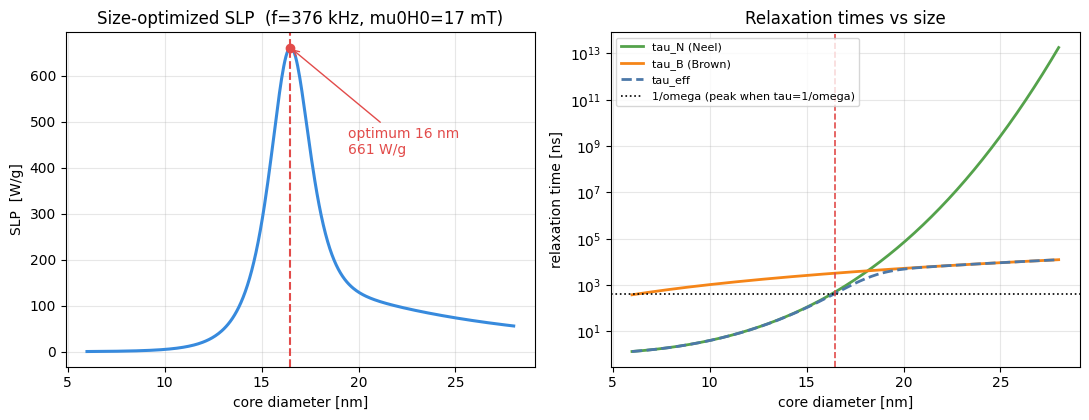

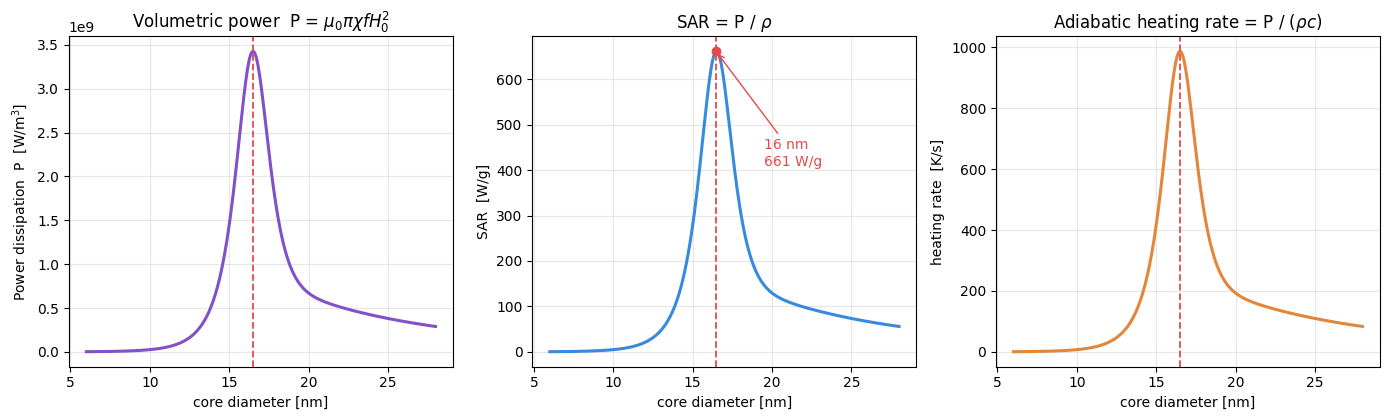

In [61]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
# =========================================================
# Khandhar, Ferguson, Simon, Krishnan (2012)
# "Enhancing cancer therapeutics using size-optimized MFH"
# Monodisperse magnetite (Fe3O4), LRT (Rosensweig) + Neel/Brown.
# Reproduce SLP vs core size -> optimum ~16 nm at f~376 kHz.
# =========================================================
kB   = 1.380649e-23        # J/K
mu0  = 4*np.pi*1e-7        # H/m
tau0 = 1e-9                # s   attempt time

# ---- magnetite parameters ----
Ms   = 446e3              # A/m    saturation magnetization
Keff = 11e3              # J/m^3  effective anisotropy (places peak near 16 nm)
rho  = 5180.0            # kg/m^3
cP   = 670.0             # J/kg/K

# ---- Khandhar operating point ----
f     = 376e3            # Hz
H_app = 13.5e3           # A/m   (mu0*H ~ 17 mT)
T     = 300.0            # K
eta   = 1.0e-3           # Pa.s  water
d_sh  = 2e-9             # m     surfactant/hydrodynamic shell
omega = 2*np.pi*f

def slp_curve(D):                       # D = core DIAMETER array (m)
    R  = D/2
    VM = (4/3)*np.pi*R**3
    VH = (4/3)*np.pi*(R+d_sh)**3
    mu = Ms*VM
    sigma  = Keff*VM/(kB*T)
    tau_n  = tau0*np.exp(sigma)
    tau_b  = 3*eta*VH/(kB*T)
    tau_e  = 1/(1/tau_n + 1/tau_b)
    xi     = mu0*mu*H_app/(kB*T)
    chi_i  = mu0*Ms**2*VM/(3*kB*T)
    chi0   = chi_i*(3/xi)*(1/np.tanh(xi) - 1/xi)     # Langevin chord
    chidp  = chi0*omega*tau_e/(1+(omega*tau_e)**2)
    P      = mu0*H_app**2*f*np.pi*chidp              # W/m^3
    return P, P/rho, tau_n, tau_b, tau_e

D = np.linspace(6e-9, 28e-9, 400)
P, SLP, tau_n, tau_b, tau_e = slp_curve(D)
SLP_g = SLP/1000                                     # W/g
iopt = np.argmax(SLP_g)
Dopt = D[iopt]*1e9
print(f"Optimum core diameter = {Dopt:.1f} nm   (peak SLP = {SLP_g[iopt]:.1f} W/g)")
print(f"at optimum: tau_eff = {tau_e[iopt]:.2e} s,  omega*tau_eff = {omega*tau_e[iopt]:.2f}")

# ================= plots =================
fig, ax = plt.subplots(1, 2, figsize=(11,4.3))

ax[0].plot(D*1e9, SLP_g, color='#378ADD', lw=2.2)
ax[0].axvline(Dopt, color='#E24B4A', ls='--', lw=1.5)
ax[0].plot(Dopt, SLP_g[iopt], 'o', color='#E24B4A')
ax[0].annotate(f'optimum {Dopt:.0f} nm\n{SLP_g[iopt]:.0f} W/g',
               xy=(Dopt, SLP_g[iopt]), xytext=(Dopt+3, SLP_g[iopt]*0.65),
               fontsize=10, color='#E24B4A',
               arrowprops=dict(arrowstyle='->', color='#E24B4A'))
ax[0].set_xlabel('core diameter [nm]')
ax[0].set_ylabel('SLP  [W/g]')
ax[0].set_title(f'Size-optimized SLP  (f={f/1e3:.0f} kHz, mu0H0={mu0*H_app*1e3:.0f} mT)')
ax[0].grid(alpha=.3)

ax[1].semilogy(D*1e9, tau_n*1e9, label='tau_N (Neel)', color='#54a24b', lw=2)
ax[1].semilogy(D*1e9, tau_b*1e9, label='tau_B (Brown)', color='#f58518', lw=2)
ax[1].semilogy(D*1e9, tau_e*1e9, label='tau_eff', color='#4c78a8', lw=2, ls='--')
ax[1].axhline(1/omega*1e9, color='k', ls=':', lw=1.2, label='1/omega (peak when tau=1/omega)')
ax[1].axvline(Dopt, color='#E24B4A', ls='--', lw=1.2)
ax[1].set_xlabel('core diameter [nm]'); ax[1].set_ylabel('relaxation time [ns]')
ax[1].set_title('Relaxation times vs size'); ax[1].legend(fontsize=8)
ax[1].grid(alpha=.3, which='both')

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(1, 3, figsize=(14,4.3))

ax[0].plot(D*1e9, P, color='#8250c8', lw=2.2)
ax[0].axvline(Dopt, color='#E24B4A', ls='--', lw=1.3)
ax[0].set_xlabel('core diameter [nm]'); ax[0].set_ylabel('Power dissipation  P  [W/m$^3$]')
ax[0].set_title('Volumetric power  P = $\\mu_0\\pi\\chi'' f H_0^2$')
ax[0].ticklabel_format(axis='y', style='sci', scilimits=(0,0)); ax[0].grid(alpha=.3)

ax[1].plot(D*1e9, SAR_g, color='#378ADD', lw=2.2)
ax[1].axvline(Dopt, color='#E24B4A', ls='--', lw=1.3)
ax[1].plot(Dopt, SAR_g[i], 'o', color='#E24B4A')
ax[1].annotate(f'{Dopt:.0f} nm\n{SAR_g[i]:.0f} W/g', xy=(Dopt,SAR_g[i]),
               xytext=(Dopt+3,SAR_g[i]*0.62), fontsize=10, color='#E24B4A',
               arrowprops=dict(arrowstyle='->', color='#E24B4A'))
ax[1].set_xlabel('core diameter [nm]'); ax[1].set_ylabel('SAR  [W/g]')
ax[1].set_title('SAR = P / $\\rho$'); ax[1].grid(alpha=.3)

ax[2].plot(D*1e9, Ts, color='#e4863a', lw=2.2)
ax[2].axvline(Dopt, color='#E24B4A', ls='--', lw=1.3)
ax[2].set_xlabel('core diameter [nm]'); ax[2].set_ylabel('heating rate  [K/s]')
ax[2].set_title('Adiabatic heating rate = P / ($\\rho c$)'); ax[2].grid(alpha=.3)

plt.tight_layout()
plt.show()

##4 J. Magn. Magn. Mater. (2015)(PMC4578659)
"Size-dependant heating rates of iron oxide nanoparticles for magnetic fluid hyperthermia"


---


| ตัวแปร | ค่า |
|---|---|
| โมเดล | ทดลอง calorimetry + LRT (ยืนยัน size-dependence ตามทฤษฎี) |
| ชนิดวัสดุ | Iron oxide (magnetite/maghemite) monodisperse เคลือบพอลิเมอร์ biocompatible, ถ่ายเข้าสู่เฟสน้ำ |
| ขนาดอนุภาค | สูงสุด ~15 nm (ควบคุมขนาดแม่นยำ) |
| ผลลัพธ์ | แสดงเป็นครั้งแรกอย่างชัดเจนว่า **heating rate ของ superparamagnetic particles ขึ้นกับขนาดอนุภาค** ที่ความถี่คงที่ |
| หมายเหตุ | ควรเปิด PDF ตัวจริงเพื่อดึง H, f, Ms, K, ρ ที่ระบุเป็นตัวเลข |

/tmp/ipykernel_718/4034377209.py:47: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return np.trapz(slp_mono(2*R)*w, R)/np.trapz(w, R)
/tmp/ipykernel_718/4034377209.py:31: RuntimeWarning: overflow encountered in exp
  tau_n = tau0*np.exp(gamma)


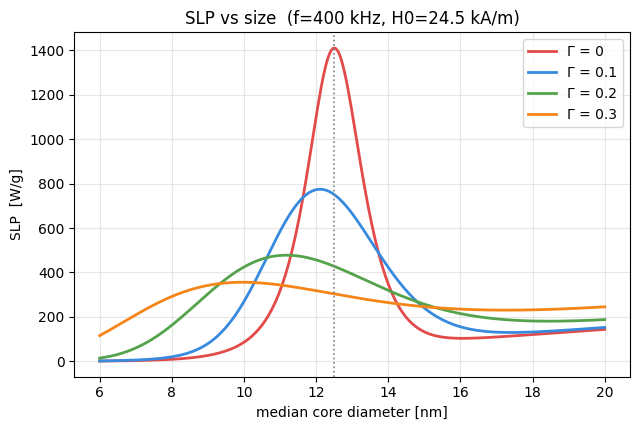

monodisperse peak at 12.5 nm


In [68]:
# ============================================================
# Gonzales-Weimuller, Zeisberger, Krishnan (2009)
# "Size-dependant heating rates of iron oxide nanoparticles for MFH"
# J. Magn. Magn. Mater. 321, 1947.  (paper #4 / nihms-721871)
# Model: LRT (Rosensweig) + Neel/Brown, initial dc susceptibility,
#        log-normal polydispersity (reproduces Fig. 3).
# ============================================================
kB   = 1.380649e-23        # J/K
mu0  = 4*np.pi*1e-7        # H/m
tau0 = 1e-9                # s   attempt time (paper: 1e-9)

# ---- material: monodisperse magnetite (paper values) ----
rho_p = 5180.0            # kg/m^3  magnetite density
Ms    = 75 * rho_p        # A/m   (paper assumed 75 emu/g -> 75 * rho)
Keff  = 2.5e4             # J/m^3 effective anisotropy (tuned so peak ~12.5 nm)

# ---- Krishnan operating point (paper) ----
f     = 400e3             # Hz
omega = 2*np.pi*f
H0    = 24.5e3            # A/m   (also measured 12.4 / 16.3 / 21.9)
T     = 300.0            # K
eta   = 1.0e-3           # Pa.s  salt water
d_sh  = 12e-9            # m     surfactant + Pluronic coating thickness

# ---- monodisperse SLP (paper eq. 2-4) ----
def slp_mono(D):                       # D = core diameter [m]
    R  = D/2
    V  = (4/3)*np.pi*R**3
    VH = (4/3)*np.pi*(R + d_sh)**3
    gamma = Keff*V/(kB*T)
    tau_n = tau0*np.exp(gamma)
    tau_b = 3*eta*VH/(kB*T)
    tau_e = 1/(1/tau_n + 1/tau_b)
    chi0  = mu0*Ms**2*V/(3*kB*T)                        # initial dc susceptibility
    chi_dp = omega*tau_e/(1+(omega*tau_e)**2)
    P     = mu0*np.pi*chi0*H0**2*f * chi_dp   # W/m^3
    return P/rho_p/1000                                 # W/g

# ---- log-normal polydispersity (paper eq. 5-6), mass-weighted ----
def slp_poly(D0, sig_ln):
    if sig_ln <= 0:
        return slp_mono(D0)
    R0 = D0/2
    R  = np.linspace(1e-9, 3*R0 + 8e-9, 300)
    g  = 1/(R*sig_ln*np.sqrt(2*np.pi))*np.exp(-(np.log(R/R0))**2/(2*sig_ln**2))
    w  = (4/3)*np.pi*R**3 * g                           # mass weight (V * number)
    return np.trapz(slp_mono(2*R)*w, R)/np.trapz(w, R)

# ---- plot: SLP vs size for several polydispersity indices (Fig. 3) ----
D = np.linspace(6e-9, 20e-9, 300)
plt.figure(figsize=(6.5, 4.4))
for g, col in [(0, '#E24B4A'), (0.1, '#378ADD'), (0.2, '#54a24b'), (0.3, '#f58518')]:
    y = np.array([slp_poly(d, g) for d in D])
    lbl = f'Γ = {g}' + (' (monodisperse)' if s == 0 else '')
    plt.plot(D*1e9, y, color=col, lw=2, label=lbl)
plt.axvline(12.5, color='0.5', ls=':', lw=1.2)
plt.xlabel('median core diameter [nm]')
plt.ylabel('SLP  [W/g]')
plt.title(f'SLP vs size  (f={f/1e3:.0f} kHz, H0={H0/1e3:.1f} kA/m)')
plt.legend(); plt.grid(alpha=.3)
plt.tight_layout()
plt.show()

imono = np.argmax([slp_mono(d) for d in D])
print(f'monodisperse peak at {D[imono]*1e9:.1f} nm')


##5 Guardia, Di Corato, Lartigue, Wilhelm, Espinosa, Garcia-Hernandez, Gazeau, Manna, Pellegrino (2012)
"Water-Soluble Iron Oxide Nanocubes with High Values of SAR for Cancer Cell Hyperthermia Treatment"

| ตัวแปร | ค่า | ที่มา |
|---|---|---|
| โมเดล | LRT (chord approximation, อ้าง Rosensweig) — สมมติ **Néel relaxation ล้วน**, τ₀ = 10⁻⁹ s | SI Appendix 1 |
| ชนิดวัสดุ | Iron oxide **nanocubes (IONC)** เคลือบพอลิเมอร์/PEG ในน้ำ | SI |
| ขนาดอนุภาค (edge length) | 12 ± 1.5, **19 ± 3**, 25 ± 4, 38 ± 9 nm | SI Fig.S1 |
| M_S | 78 / 83 / 87 / 65 A·m²·kg⁻¹ (ตามขนาด) | SI table |
| anisotropy (K_eff) | K_eff = K_V + K_S/l; **K_V = 4.7×10³ erg·cm⁻³**, K_S = 1×10⁻² erg·cm⁻² | SI Fig.S6D |
| ความเข้มสนาม | ปรับได้; ค่าเด่น **H = 29 kA·m⁻¹**; มีเส้น "biological limit" (H·f) กำกับ | SI Fig.S3–S6 |
| ความถี่ | 320 / 520 / 700 kHz | SI Fig.S3 |
| ผลลัพธ์ SAR | **สูงสุด 2452 W·g⁻¹(Fe)** ที่ 19 nm, 520 kHz, 29 kA·m⁻¹ (หนึ่งในค่าสูงสุดที่รายงาน) | abstract |
| ผลชีวภาพ | KB cells + IONC 19 nm → เซลล์ตาย ~50% เมื่อถึงสมดุล 43 °C หลัง 1 ชม. | abstract |
| ความหนืด | วัดในน้ำ (สมมติ Néel เด่นจึงไม่เน้น Brownian/η) | SI |

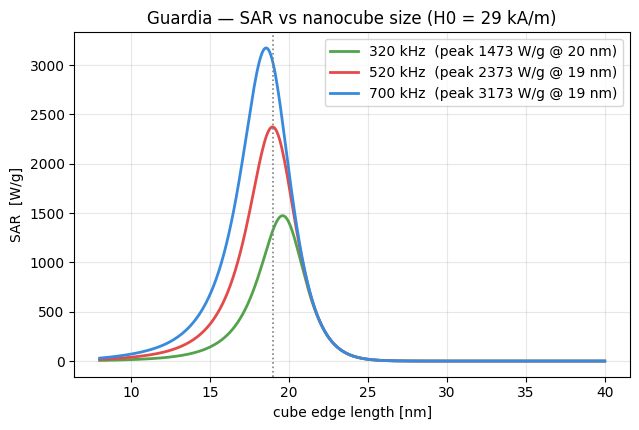

SAR(19 nm, 520 kHz) = 2372 W/g   (paper: 2452 W/g)


In [70]:
# ============================================================
#          Guardia, Di Corato, Lartigue, Wilhelm, Espinosa,
#          Garcia-Hernandez, Gazeau, Manna, Pellegrino (2012)
# "Water-Soluble Iron Oxide Nanocubes with High Values of SAR"
# ACS Nano 6, 3080.
# Model: LRT (chord), Neel relaxation, size-dependent anisotropy
#        K_eff = K_V + 6*K_S/l  (surface anisotropy of a cube).
# ============================================================
kB   = 1.380649e-23        # J/K
mu0  = 4*np.pi*1e-7        # H/m
tau0 = 1e-9                # s   attempt time (SI: 1e-9)
T    = 300.0               # K
rho  = 5180.0              # kg/m^3  iron-oxide density

# ---- size-dependent Ms (Guardia, edge length -> A m^2/kg) ----
l_pts  = np.array([12, 19, 25, 38]) * 1e-9
Ms_pts = np.array([78, 83, 87, 65]) * rho          # -> A/m
def Ms_of(l): return np.interp(l, l_pts, Ms_pts)

# ---- effective anisotropy of a nanocube (volume + surface) ----
K_V = 1.5e3      # J/m^3   volume anisotropy   (calibrated to peak @19 nm)
K_S = 6.3e-6     # J/m^2   surface anisotropy  (6/l = surface/volume of cube)
def K_eff(l): return K_V + 6*K_S/l

# ---- operating point (Guardia) ----
H0 = 29e3        # A/m
freqs = [(320e3, '#54a24b'), (520e3, '#E24B4A'), (700e3, '#378ADD')]

def sar(l, f):                       # l = cube edge length [m]
    V   = l**3                       # cube volume
    Ms  = Ms_of(l);  mu = Ms*V
    tau = tau0*np.exp(K_eff(l)*V/(kB*T))          # Neel (immobilized cubes)
    w   = 2*np.pi*f
    xi  = mu0*mu*H0/(kB*T)
    chi_i = mu0*Ms**2*V/(3*kB*T)
    chi0  = chi_i*(3/xi)*(1/np.tanh(xi) - 1/xi)   # Langevin chord
    P   = mu0*np.pi*chi0*(w*tau/(1+(w*tau)**2))*H0**2*f   # W/m^3
    return P/rho/1000                              # W/g

l = np.linspace(8e-9, 40e-9, 400)
plt.figure(figsize=(6.5, 4.4))
for f, c in freqs:
    y = sar(l, f); i = np.argmax(y)
    plt.plot(l*1e9, y, color=c, lw=2, label=f'{f/1e3:.0f} kHz  (peak {y[i]:.0f} W/g @ {l[i]*1e9:.0f} nm)')
plt.axvline(19, color='0.5', ls=':', lw=1.2)
plt.xlabel('cube edge length [nm]'); plt.ylabel('SAR  [W/g]')
plt.title('Guardia — SAR vs nanocube size (H0 = 29 kA/m)')
plt.legend(); plt.grid(alpha=.3); plt.tight_layout()
plt.show()

print(f'SAR(19 nm, 520 kHz) = {sar(19e-9, 520e3):.0f} W/g   (paper: 2452 W/g)')